In [1]:
from itertools import product
import logging
import os
import pickle
import sys

import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy import stats
from scipy.spatial import Delaunay, delaunay_plot_2d

from eryn.ensemble import EnsembleSampler
from eryn.moves import DistributionGenerateRJ, StretchMove, GaussianMove
from eryn.prior import uniform_dist, ProbDistContainer
from eryn.state import State

import corner
from tqdm import trange

from local_utils import delaunaytor
from local_utils.moves import BinGaussRelMove

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
plt.style.use("tableau-colorblind10")

plt.rcParams["font.family"] = "serif"
plt.rcParams["text.usetex"] = True
plt.rcParams["font.size"] = 20

In [2]:
parameter_keys = ["m1", "z", "q", "chi1", "chi2", "tilt1", "tilt2"]

data_file = np.load("./lvc_data_lvc_samples_full.npz")
observed_events = np.vstack([data_file[key + "s"] for key in parameter_keys]).T
num_events = data_file["nevents"][0]
num_samples = data_file["nsamples"][0]

event_barycenters = observed_events.reshape(
    (num_events, num_samples, observed_events.shape[-1])
).mean(axis=1)

In [3]:
def triangulation_sizes(backend_file, nsteps, walkers=None):
    
    walkers = walkers or range(20)
    
    with open(backend_file, "rb") as f:
        back = pickle.load(f)
    return np.array([
        back.inds["tri"][step, 0, walker].sum()
        for step, walker in product(range(nsteps), walkers)
    ])

# num_runs = 10
# nwalkers = 40
# nsteps = 1000
num_runs = 1
nwalkers = 40
nsteps = 100

z_min = 1e-6
z_max = 2.3
m1_min = 2. 
m1_max = 100. + 1e-6
q_min = 0.
q_max = 1.

corners = np.array([
        [m1_min, z_min, q_min],
        [m1_min, z_min, q_max],
        [m1_min, z_max, q_min],
        [m1_min, z_max, q_max],
        [m1_max, z_min, q_min],
        [m1_max, z_min, q_max],
        [m1_max, z_max, q_min],
        [m1_max, z_max, q_max],
    ])



test/backend read...
[ 6. 16. 30.]


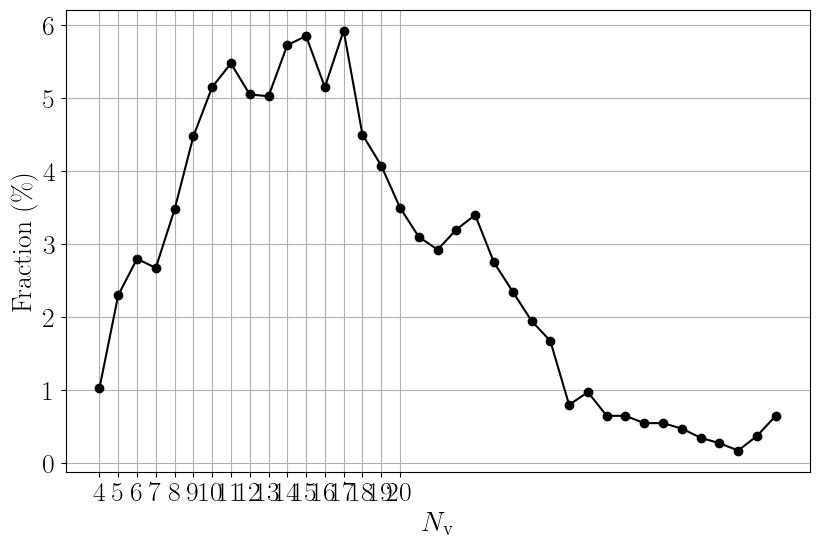

In [10]:
fig, ax = plt.subplots(figsize=(1.2 * 8, 1.2 * 5))
ax.grid(which="both")
ax.set(
    yscale="linear",
    xlabel=r"$N_{\mathrm{v}}$",
    ylabel=r"Fraction (\%)"
)
ax.set_xticks(np.arange(4, 21, 1)) 

# tri_sizes = []
# for run in range(num_runs):

#     try:
#         tri_sizes.append(
#             triangulation_sizes(
#                 name := f"results_run_{run}/backend",
#                 nsteps,
#                 walkers=range(nwalkers)
#             )
#         )
#         print(f"{name} read...")
#     except:
#         print(f"{name} missing")
#         continue

# tri_sizes = np.vstack(tri_sizes)

try:
    tri_sizes = triangulation_sizes(
            name := f"test/backend",
            nsteps,
            walkers=range(nwalkers))
    print(f"{name} read...")
except:
    print(f"{name} missing")

print(np.quantile(tri_sizes, [0.05, 0.5, 0.95]))

bins, counts = np.unique(tri_sizes, return_counts=True)
ax.plot(bins, 100 * counts / counts.sum(), "o-", color="black")

plt.show()
plt.close()

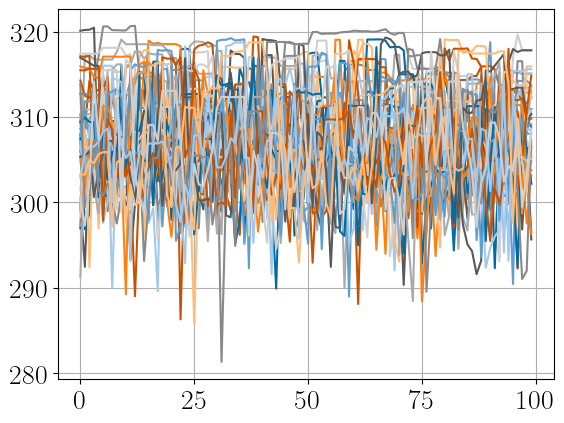

In [12]:
# for run_label in range(8):#range(num_runs):
#     fig, ax = plt.subplots()
#     ax.set_rasterized(True)
#     ax.grid()

#     with open(f"results_run_{run_label}/backend", "rb") as f:
#         back = pickle.load(f)



#     for w in range(nwalkers):
#         ax.plot(back.get_log_like()[:, 0, w], label=w)
#     ax.legend()
#     plt.show()
#     plt.close()

fig, ax = plt.subplots()
ax.set_rasterized(True)
ax.grid()

with open(f"test/backend", "rb") as f:
    back = pickle.load(f)

for w in range(nwalkers):
    ax.plot(back.get_log_like()[:, 0, w], label=w)
#ax.legend()
plt.show()
plt.close()

In [14]:
# all_triangulations = []
# for run_label in range(num_runs): #range(num_runs):
#     try:
#         with open(f"results_run_{run_label}/backend", "rb") as f:
#             back = pickle.load(f)
#             triangulations = [
#                 back.chain["tri"][step, 0, walker][back.inds["tri"][step, 0, walker]]
#                 for step, walker in product(range(nsteps), range(nwalkers))
#             ]

#             corner_weights = np.array(
#                 [
#                     back.chain["corner_w"][step, 0, walker]
#                     for step, walker in product(range(nsteps), range(nwalkers))
#                 ]
#             )

#             chi = np.array(
#                 [
#                     back.chain["chi"][step, 0, walker]
#                     for step, walker in product(range(nsteps), range(nwalkers))
#                 ]
#             )

#             tilt = np.array(
#                 [
#                     back.chain["tilt"][step, 0, walker]
#                     for step, walker in product(range(nsteps), range(nwalkers))
#                 ]
#             )


#         all_triangulations.extend([
#             np.vstack([
#                 triangulations[ind], 
#                 np.c_[corners, corner_weights[ind].T]
#             ])
#             for ind in range(len(triangulations))
#         ])
#     except:
#         print("Fish")
# triangulations = all_triangulations
all_triangulations = []
with open(f"test/backend", "rb") as f:
    back = pickle.load(f)
    triangulations = [
        back.chain["tri"][step, 0, walker][back.inds["tri"][step, 0, walker]]
        for step, walker in product(range(nsteps), range(nwalkers))
    ]

    corner_weights = np.array(
        [
            back.chain["corner_w"][step, 0, walker]
            for step, walker in product(range(nsteps), range(nwalkers))
        ]
    )

    chi = np.array(
        [
            back.chain["chi"][step, 0, walker]
            for step, walker in product(range(nsteps), range(nwalkers))
        ]
    )

    tilt = np.array(
        [
            back.chain["tilt"][step, 0, walker]
            for step, walker in product(range(nsteps), range(nwalkers))
        ]
    )


all_triangulations.extend([
    np.vstack([
        triangulations[ind], 
        np.c_[corners, corner_weights[ind].T]
    ])
    for ind in range(len(triangulations))
])

In [15]:
from astropy.cosmology import Planck15
from astropy import units as u
# >>> file_vt=h5py.File('o1+o2+o3_bbhpop_real+semianalytic-LIGO-T2100377-v2.hdf5')
# >>> Tobs=file_vt['injections'].attrs["analysis_time_s"]
Tobs = 63129577.0 / 86400 / 365 # years

<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\,'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_28034/737536389.py:69: SyntaxWarning: invalid escape sequence '\m'
  + "\mathcal{R}^{50\%}"
/tmp/ipykernel_28034/737536389.py:70: SyntaxWarning: invalid escape sequence '\,'
  + " \, [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1} \mathrm{M}_{\odot}^{-1}]$"


Creating animation with 100 frames...
Computing color range...


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


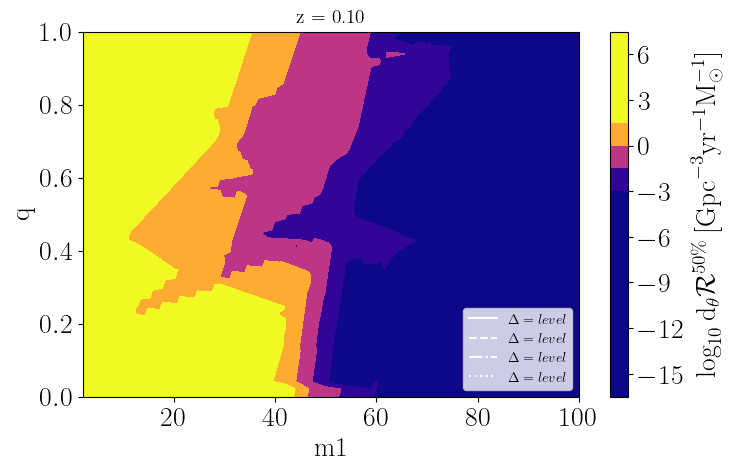

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.lines as mlines
from IPython.display import HTML

# Compressed parameters for notebook
m1_points = np.linspace(m1_min, m1_max, 200)  # Reduced from 50
q_points = np.linspace(q_min, q_max, 50)      # Reduced from 10
M1, Q = np.meshgrid(m1_points, q_points)

m1_flat = M1.ravel()
q_flat = Q.ravel()

# Fewer z values for faster computation
z_values = np.linspace(0.1, 2.3, 100)  # Reduced from 20

def compute_rates_for_z(z_value):
    """Compute rates for given z value"""
   
    log10_rate = np.zeros((num_tris := (len(triangulations)//500), M1.ravel().shape[0]))
    
    for ind, tri in enumerate(triangulations[::500]):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(tri)
        log10_rate[ind] = this_delo.interpolate(
            np.c_[m1_flat, z_value * np.ones_like(m1_flat), q_flat]
        ) / np.log(10)
    
    to_comoving_volume = (1 + z_value) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_value).to(u.Gpc**3 / u.sr).value
    )
    
    square_rate = (
        log10_rate.reshape(num_tris, q_points.shape[0], m1_points.shape[0])
        + np.log10(to_comoving_volume)
    )
    
    return (np.quantile(square_rate, 0.5, axis=0),
            np.quantile(square_rate, 0.05, axis=0),
            np.quantile(square_rate, 0.95, axis=0))

def create_notebook_animation():
    """Optimized animation for Jupyter notebooks"""
    fig, ax = plt.subplots(figsize=(8, 5))
    plt.subplots_adjust(bottom=0.15)
    
    # Simplified overlay levels
    levels_overlay = [1., 3, 5, 7]
    linestyles = ['solid', 'dashed', 'dashdot', ":"]
    
    print("Computing color range...")
    sample_medians = []
    for z in z_values[::10]:  # Sample every 10th frame
        median, _, _ = compute_rates_for_z(z)
        sample_medians.append(median)
    
    vmin = -2.5
    vmax = 1.5
    
    # Create colorbar ONCE, outside the animation function
    median_0, _, _ = compute_rates_for_z(z_values[0])
    c_initial = ax.contourf(m1_points, q_points, median_0, 
                           levels=20, cmap="plasma", vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(
        c_initial,
        ax=ax, 
        label=r"$\log_{10} \mathrm{d}_{\theta} " 
        + "\mathcal{R}^{50\%}"
        + " \, [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1} \mathrm{M}_{\odot}^{-1}]$"

    )  # ONLY ONCE!
    
    
    def animate(frame):
        ax.clear()
        z_current = z_values[frame]
        
        # Compute data
        median, low, high = compute_rates_for_z(z_current)
        
        # Main contour (fewer levels for speed)
        c = ax.contourf(m1_points, q_points, median, vmin=vmin, vmax=vmax,
                       levels=20, cmap="plasma", antialiased=False)
        
        # Simplified overlay
        error_data = (high - low)
        for level, style in zip(levels_overlay, linestyles):
            ax.contour(m1_points, q_points, error_data, levels=[level],
                      colors='white', linewidths=1.5, linestyles=style)
        
        # Minimal legend
        handles = [mlines.Line2D([], [], color='white', linestyle=style, 
                               label=r'$\Delta={level}$') 
                  for level, style in zip(levels_overlay, linestyles)]
        ax.legend(handles=handles, loc="lower right", fontsize=10)
        
        ax.set_title(f'z = {z_current:.2f}', fontsize=14)
        ax.set_xlabel('m1')
        ax.set_ylabel('q')
        
    return FuncAnimation(fig, animate, frames=len(z_values), 
                        interval=50, blit=False, repeat=True)

    
# Create and display animation
print(f"Creating animation with {len(z_values)} frames...")
anim = create_notebook_animation()

# For Jupyter notebooks - display as HTML
from IPython.display import HTML
HTML(anim.to_jshtml())

<>:18: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_28034/458849477.py:18: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$m_1 \, [\mathrm{M}_{\odot}]$')
/tmp/ipykernel_28034/458849477.py:40: RuntimeWarning: overflow encountered in power
  mask = np.log10(10**high - 10**low) < 1 # The gray goes on the False


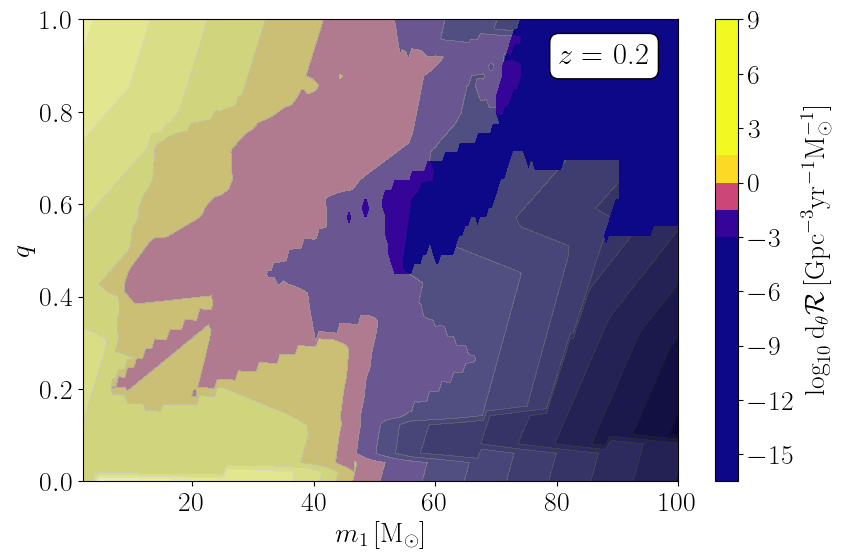

/tmp/ipykernel_28034/458849477.py:40: RuntimeWarning: overflow encountered in power
  mask = np.log10(10**high - 10**low) < 1 # The gray goes on the False


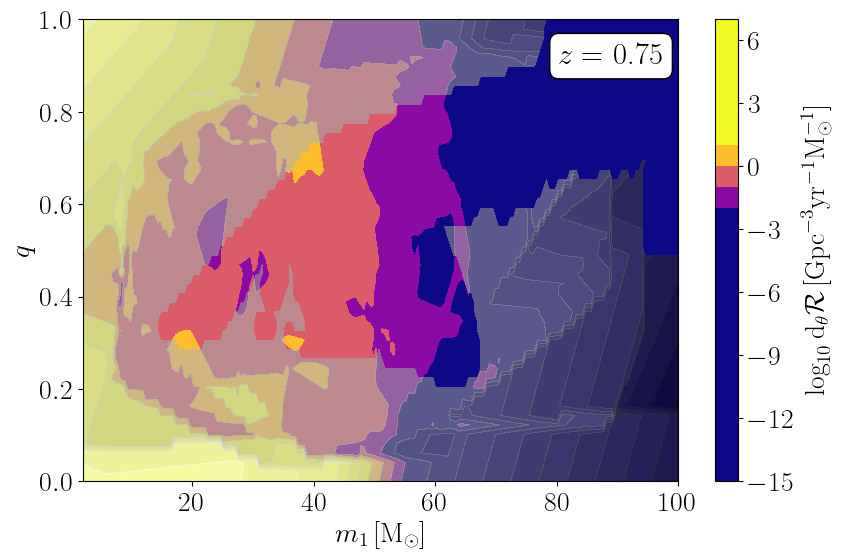

/tmp/ipykernel_28034/458849477.py:40: RuntimeWarning: overflow encountered in power
  mask = np.log10(10**high - 10**low) < 1 # The gray goes on the False


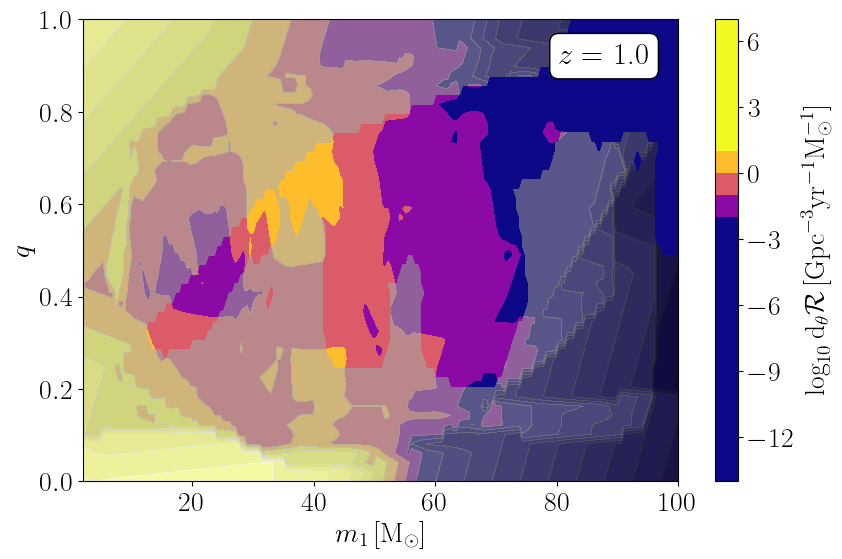

/tmp/ipykernel_28034/458849477.py:40: RuntimeWarning: overflow encountered in power
  mask = np.log10(10**high - 10**low) < 1 # The gray goes on the False


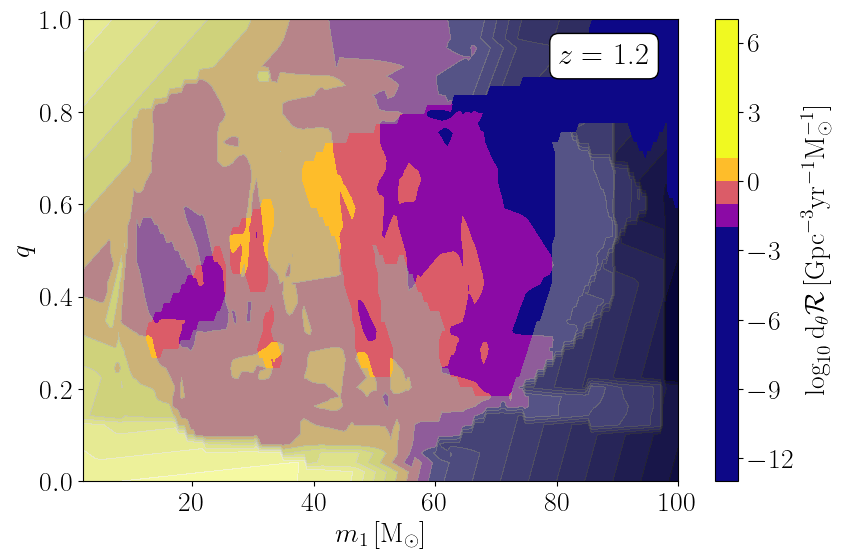

In [19]:
# Compressed parameters for notebook
m1_points = np.linspace(m1_min, m1_max, 200)  # Reduced from 50
q_points = np.linspace(q_min, q_max, 50)      # Reduced from 10
M1, Q = np.meshgrid(m1_points, q_points)

m1_flat = M1.ravel()
q_flat = Q.ravel()

for z_value in [0.2, 0.75, 1.0, 1.20]:
    
    levels_overlay = [1., 1.5, 2, 2.5]
    linestyles = ['solid', 'dashed', 'dashdot', ":"]

    vmin = -2.5
    vmax = 1.

    fig, ax = plt.subplots(figsize=(1.2 * 8, 1.2 * 5))
    ax.set_xlabel('$m_1 \, [\mathrm{M}_{\odot}]$')
    ax.set_ylabel('$q$')

    # Compute data
    median, low, high = compute_rates_for_z(z_value)

    
    #c = ax.contourf(X, Y, data, levels=20, cmap='viridis')
    #plt.colorbar(c, ax=ax, label="Data value")

    
    # Main contour
    c = ax.contourf(
        m1_points, q_points, median, vmin=vmin, vmax=vmax, levels=20, cmap="plasma", antialiased=False
    )

    # for coll in c.collections:
    #     coll.set_rasterized(True)



    # Overlay contour for error
    mask = np.log10(10**high - 10**low) < 1 # The gray goes on the False
    masked_data = np.ma.masked_array(median, mask)
    ax.contourf(m1_points, q_points, masked_data, levels=20, cmap='gray', alpha=0.6)
    
    cbar = fig.colorbar(
        c,
        ax=ax, 
        label=r"$\log_{10} \mathrm{d}_{\theta} \mathcal{R} \, [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1} \mathrm{M}_{\odot}^{-1}]$"
    )
    
    ax.text(
        0.8, 0.95,       # x, y position in axes fraction (0=left/bottom, 1=right/top)
        f"$z = $ " + f"{z_value}",      # Text to display
        transform=ax.transAxes,
        fontsize=22,
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=1, boxstyle="round"),
    )



    fig.savefig(f"m1_q_z_{z_value}.pdf", bbox_inches="tight")
    plt.show()

In [20]:
def rate_z_marg_q(z):
    """Compute rates for given z value"""
    from scipy.special import logsumexp

    log_rate = np.zeros((num_tris := (len(triangulations)//500), M1.ravel().shape[0]))
    
    for ind, tri in enumerate(triangulations[::500]):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(tri)
        log_rate[ind] = this_delo.interpolate(
            np.c_[m1_flat, z_value * np.ones_like(m1_flat), q_flat]
        )
    
    to_comoving_volume = (1 + z) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z).to(u.Gpc**3 / u.sr).value
    )
    
    marg_rate = logsumexp(
        log_rate.reshape(num_tris, q_points.shape[0], m1_points.shape[0]) 
        + np.log(to_comoving_volume)
        + np.log(q_points[1] - q_points[0]),
        axis=1,
    ) / np.log(10.)
    
    return (np.quantile(marg_rate, 0.5, axis=0),
            np.quantile(marg_rate, 0.05, axis=0),
            np.quantile(marg_rate, 0.95, axis=0))

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_28034/4224338403.py:5: SyntaxWarning: invalid escape sequence '\m'
  xlabel="$m_1$ [$\mathrm{M}_{\odot}$]",


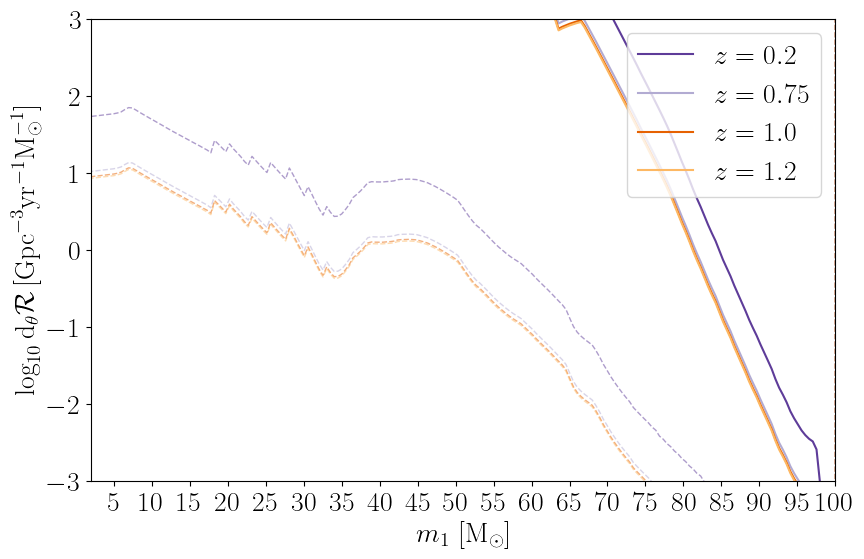

In [21]:
fig, ax = plt.subplots(figsize=(1.2 * 8, 1.2 * 5))
ax.set(
    xlim=(2, 100), 
    ylim=(-3, 3),
    xlabel="r$m_1$ [$\mathrm{M}_{\odot}$]",
    ylabel=r"$\log_{10} \mathrm{d}_{\theta}\mathcal{R} \, [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1} \mathrm{M}_{\odot}^{-1}]$"
)
ax.set_xticks(np.arange(5, 105, 5))


colors = ['#5e3c99', '#b2abd2', '#e66101','#fdb863']

for ind, z in enumerate([0.2, 0.75, 1., 1.2]):
    
    m, l, h = rate_z_marg_q(z)
    
    line, = ax.plot(m1_points, m, label=fr"${z=}$", color=colors[ind])
    ax.fill_between(m1_points, l, h, color="none", edgecolor=colors[ind], alpha=0.5, ls="--")

    
ax.legend(loc="upper right")
plt.show()

fig.savefig("rate_z_marg_q.pdf", bbox_inches="tight")

plt.close()

ValueError: x and y must have same first dimension, but have shapes (200,) and (50, 200)

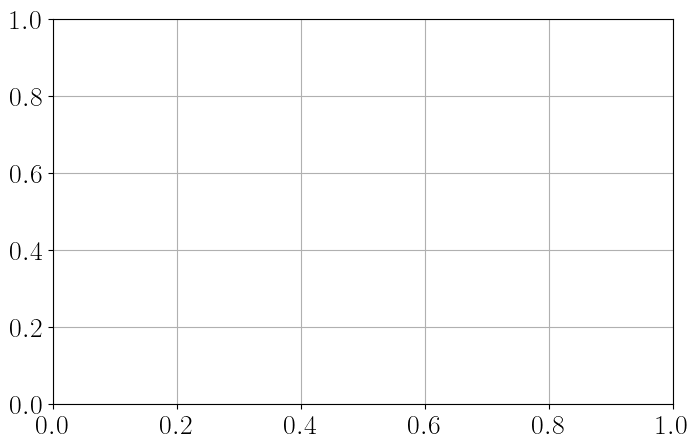

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.grid()

q_value = 0.75
for z in [0.2, 0.9]:
    
    # m, l, h = compute_rates_for_z(z, q_value)
    m, l, h = compute_rates_for_z(z)
    
    line, = ax.plot(m1_points, m)
    ax.fill_between(m1_points, l, h, color=line.get_color(), alpha=0.5)
    
plt.show()
plt.close()

In [25]:
# anim.save('my_masked_animation.gif',  fps=15, bitrate=1800)

In [27]:
samples_per_tri = 100
num_tris = len(triangulations[::200])

samples = np.zeros((num_tris * samples_per_tri, 3))

for ind, tri in enumerate(triangulations[::200]):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri)
    samples[samples_per_tri * ind : samples_per_tri * (ind + 1)] = this_delo.sample(samples_per_tri)

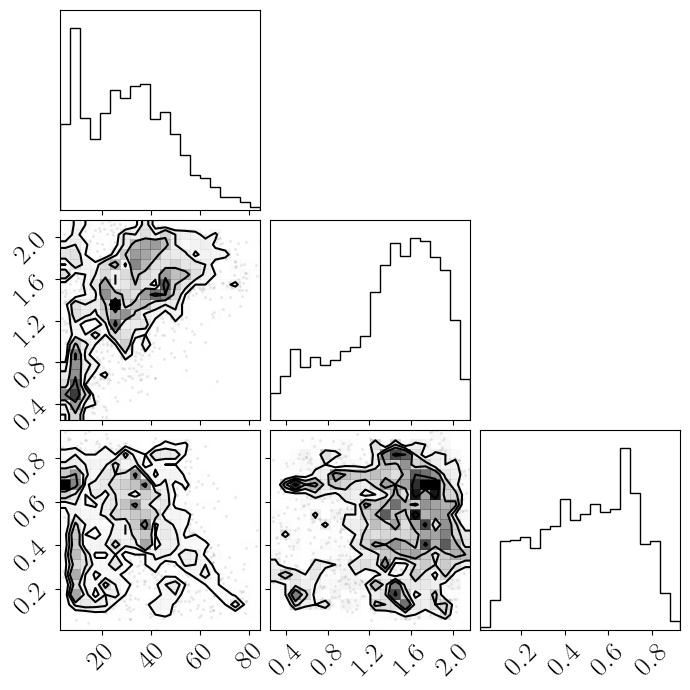

In [30]:
corner.corner(samples)
plt.show()
plt.close()

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_28034/218924387.py:6: SyntaxWarning: invalid escape sequence '\m'
  ylabel="$p_{\mathrm{pop}}(" + f"{label}" + ")$",


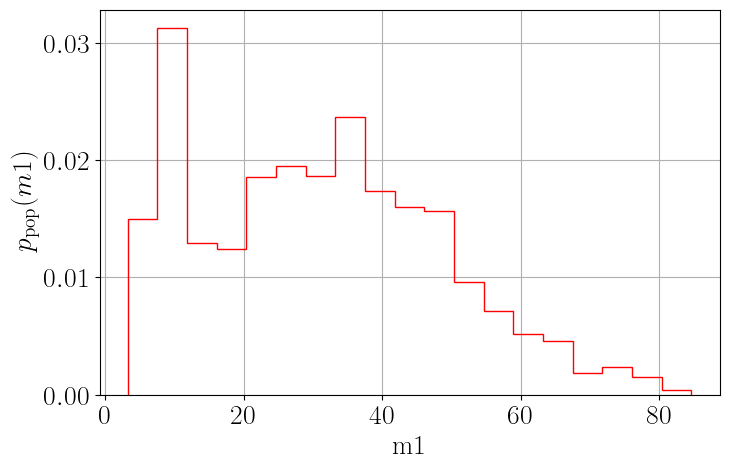

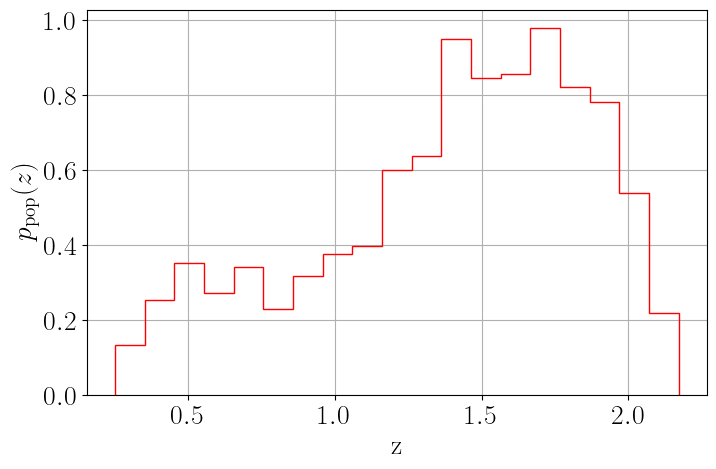

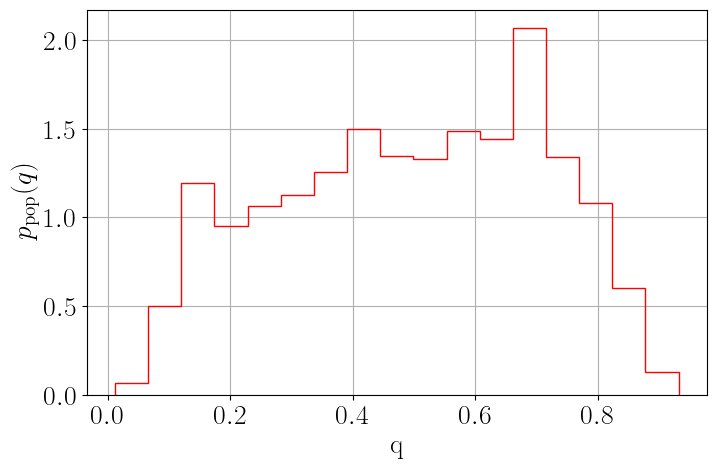

In [31]:
for theta, label in enumerate(["m1", "z", "q"]):

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set(
        xlabel=f"{label}", 
        ylabel="$p_{\mathrm{pop}}(" + f"{label}" + ")$",
    )
    ax.grid()

    ax.hist(
        samples[:, theta],
        bins="auto",
        color="red",
        density=True,
        histtype="step",
    )

    plt.show()
    plt.close()